In [76]:
import pandas as pd

df = pd.read_csv("data/reduced_world_real_estate_data.csv")

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Country             144961 non-null  object 
 1   Property Type       144961 non-null  object 
 2   Value & Size        144961 non-null  float64
 3   Height              144961 non-null  float64
 4   Building Age        144961 non-null  float64
 5   Interior Amenities  144961 non-null  float64
 6   Residual Factor     144961 non-null  float64
dtypes: float64(5), object(2)
memory usage: 7.7+ MB


In [78]:
pc_columns = [
    'Value & Size', 
    'Height', 
    'Building Age', 
    'Interior Amenities', 
    'Residual Factor'
]

country_comparison_df = df.groupby('Country')[pc_columns].mean()

country_comparison_df = country_comparison_df.sort_values(by='Value & Size', ascending=False)

print("\n--- Country comparison table (Top 10 countries by Value & Size) ---")
print(country_comparison_df.head(10))


--- Country comparison table (Top 10 countries by Value & Size) ---
               Value & Size    Height  Building Age  Interior Amenities  \
Country                                                                   
Italy              2.101079  0.488951     -0.658187           -0.189601   
Greece             1.512354 -0.285972     -0.103571           -0.295321   
Croatia            1.501101 -0.287911     -0.625437           -0.060228   
United States      1.465724  0.982700     -0.256712            0.392628   
Portugal           1.244133  1.269306     -0.620713           -0.209046   
Spain              1.130495  0.682867     -0.126799           -0.032854   
Latvia             0.760734  0.454685     -0.134406            0.135250   
Montenegro         0.648376  0.450837      0.101760           -0.149998   
Austria            0.161320  0.165106     -1.157276           -0.138387   
Hungary            0.123108 -1.024008      0.019391           -0.070864   

               Residual Factor

In [79]:
df.describe(include='all')

,Country,Property Type,Value & Size,Height,Building Age,Interior Amenities,Residual Factor
count,144961,144961,144961.000000,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05
unique,27,4,NaN,NaN,NaN,NaN,NaN
top,Turkey,apartment,NaN,NaN,NaN,NaN,NaN
freq,25681,97212,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.000000,-2.509626e-17,-1.882219e-17,6.274065e-18,-9.411097e-18
std,NaN,NaN,1.792876,1.509595e+00,1.134929e+00,1.079830e+00,9.230684e-01
min,NaN,NaN,-8.283624,-1.003060e+01,-4.943979e+01,-4.928472e+01,-7.005565e+00
25%,NaN,NaN,-1.201268,-4.626960e-01,-3.250649e-01,-5.829254e-01,-4.765734e-01
50%,NaN,NaN,-0.272264,2.589682e-01,1.279291e-01,-1.336184e-01,-1.018872e-02
75%,NaN,NaN,1.006985,8.416067e-01,5.831365e-01,4.345905e-01,3.636975e-01


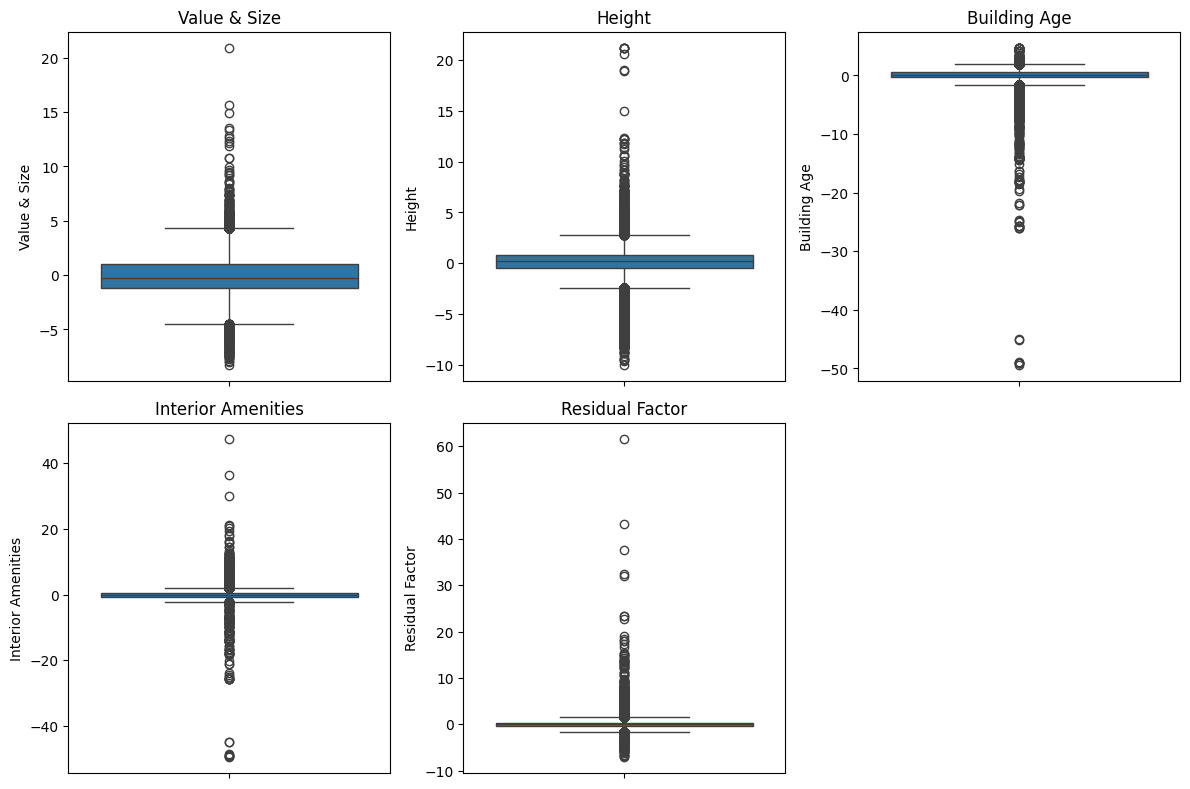

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [ 'Value & Size', 'Height', 'Building Age', 'Interior Amenities', 'Residual Factor']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

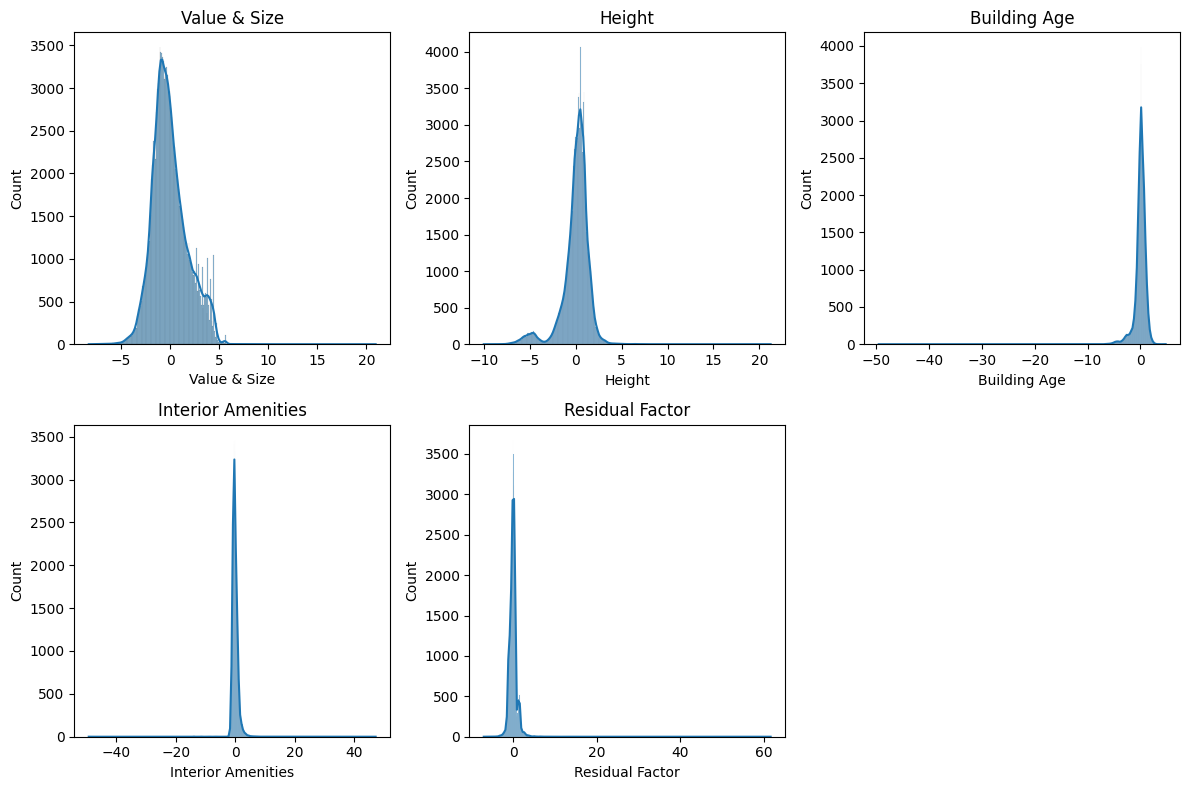

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Value & Size', 'Height', 'Building Age', 'Interior Amenities', 'Residual Factor']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


In [82]:
from scipy import stats
import numpy as np

zscore_mask = np.zeros(len(df), dtype=bool)
zscore_info = {}

for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    mask = z_scores > 3  
    zscore_info[col] = mask.sum()
    zscore_mask |= mask

df['is_outlier_zscore'] = zscore_mask
print("Z-Score Outliers (|z| > 3):")
print(f"Total: {df['is_outlier_zscore'].sum()} ({df['is_outlier_zscore'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in zscore_info.items():
    print(f"  {col}: {count}")

Z-Score Outliers (|z| > 3):
Total: 7675 (5.29%)

Outliers per PC:
  Value & Size: 391
  Height: 4863
  Building Age: 2247
  Interior Amenities: 1421
  Residual Factor: 1705


In [83]:
outlier_mask = np.zeros(len(df), dtype=bool)
outlier_info = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_info[col] = mask.sum()  
    outlier_mask |= mask

df['is_outlier_iqr'] = outlier_mask
print("IQR Outliers (1.5 * IQR rule):")
print(f"Total: {df['is_outlier_iqr'].sum()} ({df['is_outlier_iqr'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in outlier_info.items():
    print(f"  {col}: {count}")

IQR Outliers (1.5 * IQR rule):
Total: 19313 (13.32%)

Outliers per PC:
  Value & Size: 2700
  Height: 9082
  Building Age: 9081
  Interior Amenities: 4736
  Residual Factor: 6898


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Country             144961 non-null  object 
 1   Property Type       144961 non-null  object 
 2   Value & Size        144961 non-null  float64
 3   Height              144961 non-null  float64
 4   Building Age        144961 non-null  float64
 5   Interior Amenities  144961 non-null  float64
 6   Residual Factor     144961 non-null  float64
 7   is_outlier_zscore   144961 non-null  bool   
 8   is_outlier_iqr      144961 non-null  bool   
dtypes: bool(2), float64(5), object(2)
memory usage: 8.0+ MB


In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

COL_TO_TEST = 'Value & Size' 
df_col = df[COL_TO_TEST]

Q1 = df_col.quantile(0.25)
Q3 = df_col.quantile(0.75)
IQR = Q3 - Q1
IQR_LOWER = Q1 - 1.5 * IQR
IQR_UPPER = Q3 + 1.5 * IQR

iqr_outliers_mask = (df_col < IQR_LOWER) | (df_col > IQR_UPPER)
iqr_outlier_count = iqr_outliers_mask.sum()

mean = df_col.mean()
std = df_col.std()
Z_SCORE_LIMIT = 3

Z_LOWER = mean - Z_SCORE_LIMIT * std
Z_UPPER = mean + Z_SCORE_LIMIT * std

zscore_outliers_mask = (df_col < Z_LOWER) | (df_col > Z_UPPER)
zscore_outlier_count = zscore_outliers_mask.sum()

common_outliers_mask = iqr_outliers_mask & zscore_outliers_mask
common_outlier_count = common_outliers_mask.sum()

print(f"--- Comparing found outliers for column: {COL_TO_TEST} ---")
print(f"Total observations: {len(df)}")
print("-" * 50)
print(f"Outliers detected by IQR: {iqr_outlier_count}")
print(f"Outliers detected by Z-score: {zscore_outlier_count}")
print(f"Outliers common to both methods: {common_outlier_count}")

--- Comparing found outliers for column: Value & Size ---
Total observations: 144961
--------------------------------------------------
Outliers detected by IQR: 2700
Outliers detected by Z-score: 391
Outliers common to both methods: 391


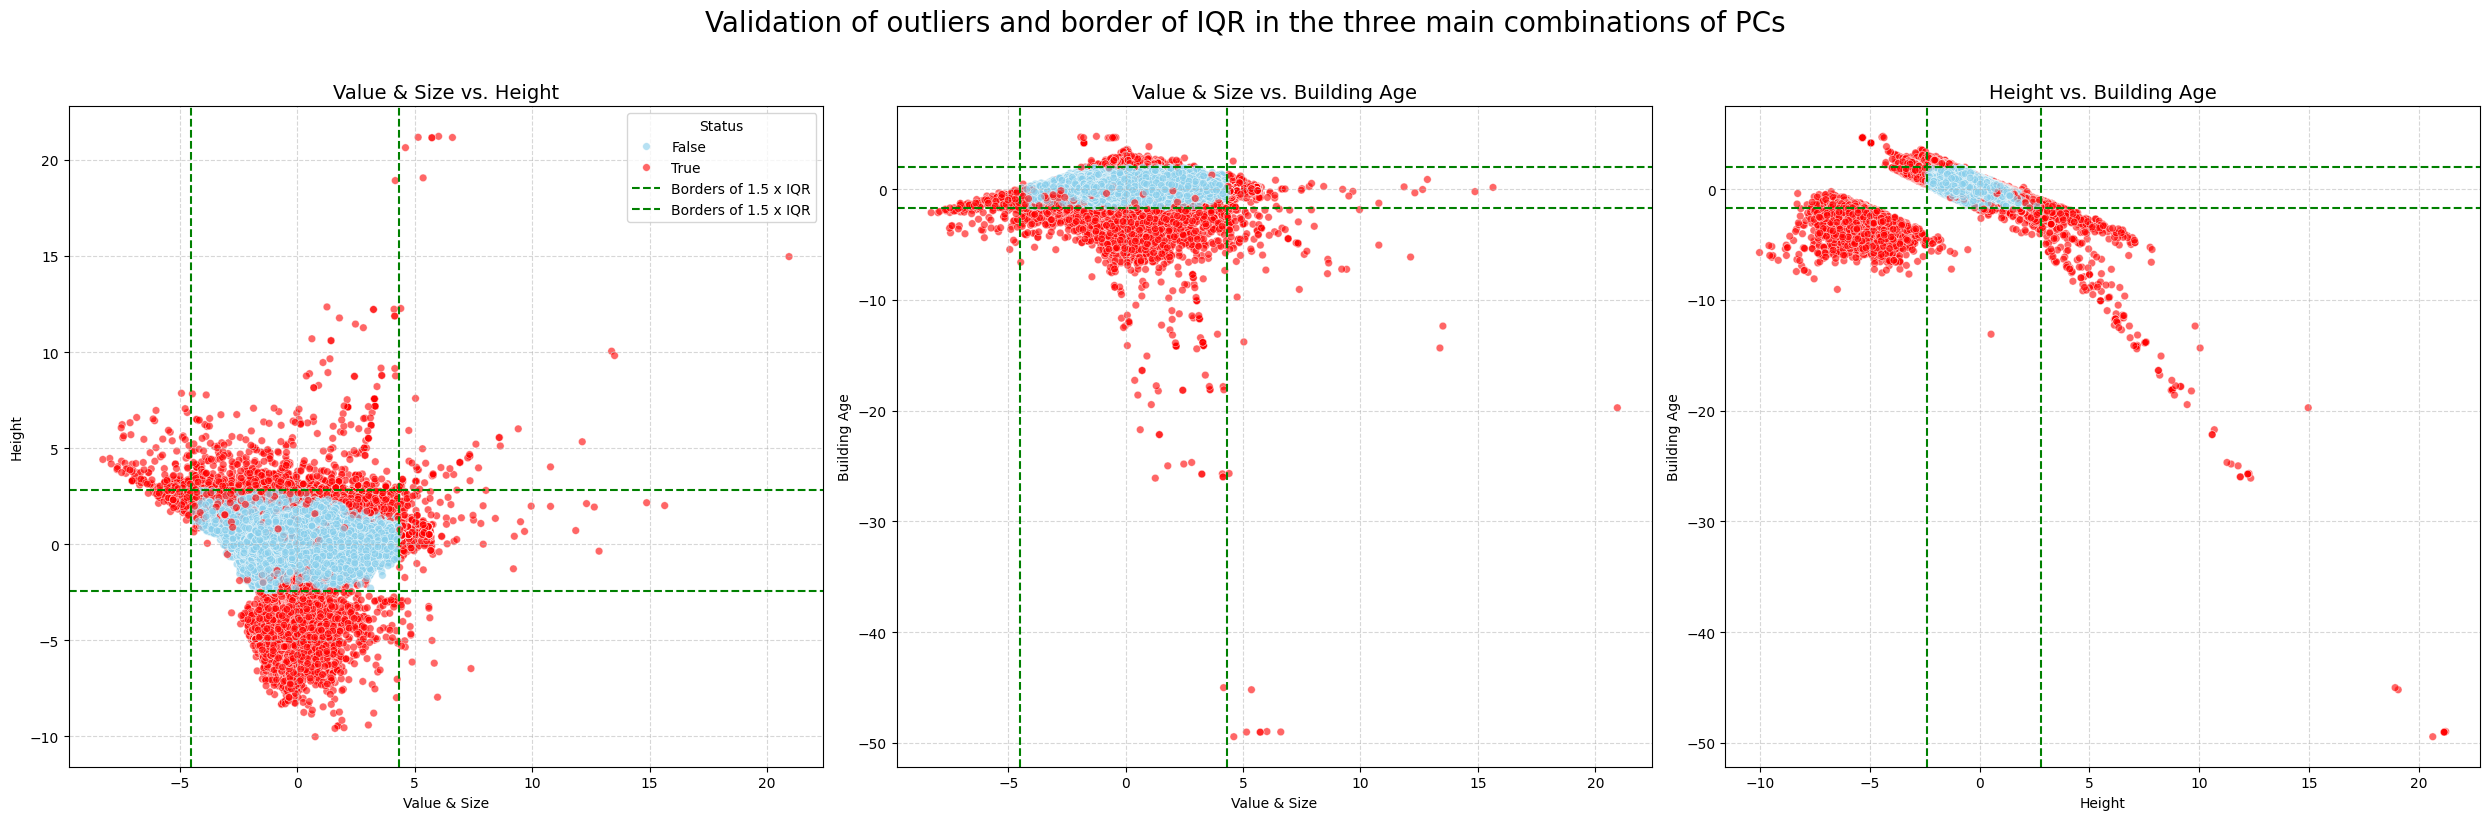

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

pc_pairs = [
    ('Value & Size', 'Height'),
    ('Value & Size', 'Building Age'),
    ('Height', 'Building Age')
]

fig, axes = plt.subplots(1, 3, figsize=(25, 8))

plt.suptitle('Validation of outliers and border of IQR in the three main combinations of PCs', fontsize=20, y=1.02)

for i, (pc_x, pc_y) in enumerate(pc_pairs):
    ax = axes[i]
    
    Q1_x, Q3_x = df[pc_x].quantile(0.25), df[pc_x].quantile(0.75)
    IQR_x = Q3_x - Q1_x
    LOWER_x, UPPER_x = Q1_x - 1.5 * IQR_x, Q3_x + 1.5 * IQR_x
    
    Q1_y, Q3_y = df[pc_y].quantile(0.25), df[pc_y].quantile(0.75)
    IQR_y = Q3_y - Q1_y
    LOWER_y, UPPER_y = Q1_y - 1.5 * IQR_y, Q3_y + 1.5 * IQR_y
    
    sns.scatterplot(
        data=df, 
        x=pc_x, 
        y=pc_y, 
        hue='is_outlier_iqr', 
        palette={True: 'red', False: 'skyblue'},
        alpha=0.6, 
        s=30,
        hue_order=[False, True],
        ax=ax
    )
    
    ax.axvline(LOWER_x, color='green', linestyle='--', linewidth=1.5)
    ax.axvline(UPPER_x, color='green', linestyle='--', linewidth=1.5)
    ax.axhline(LOWER_y, color='green', linestyle='--', linewidth=1.5)
    ax.axhline(UPPER_y, color='green', linestyle='--', linewidth=1.5, label='Borders of 1.5 x IQR')
    
    ax.set_title(f'{pc_x} vs. {pc_y}', fontsize=14)
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        handles.append(plt.Line2D([0], [0], color='green', linestyle='--', linewidth=1.5))
        labels.append('Borders of 1.5 x IQR')
        ax.legend(handles, labels, title='Status', loc='best')
    else:
        ax.legend_.remove()

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

In [87]:
import numpy as np
from scipy.stats import chi2
import pandas as pd

pc_cols = [
    'Value & Size', 
    'Height', 
    'Building Age', 
    'Interior Amenities', 
    'Residual Factor'
]

X = df[pc_cols].values
N = len(X)
dof = len(pc_cols)

mu = X.mean(axis=0)
Sigma = np.cov(X.T)
try:
    Sigma_inv = np.linalg.inv(Sigma)
except np.linalg.LinAlgError:
    print("Error: Covariance matrix is not invertible. Using pseudo-inverse instead.")
    Sigma_inv = np.linalg.pinv(Sigma)
    Sigma_inv = np.eye(dof)

mahalanobis_distances_squared = []
for i in range(N):
    x_minus_mu = X[i, :] - mu
    dm_squared = x_minus_mu.T @ Sigma_inv @ x_minus_mu
    mahalanobis_distances_squared.append(dm_squared)

df['Mahalanobis_Distance_Squared'] = mahalanobis_distances_squared

alpha = 0.001 
cutoff = chi2.ppf(1 - alpha, dof)

df['is_outlier_mahalanobis'] = df['Mahalanobis_Distance_Squared'] > cutoff

# Rezultatet
mahalanobis_outlier_count = df['is_outlier_mahalanobis'].sum()
mahalanobis_percentage = df['is_outlier_mahalanobis'].mean() * 100

print("\n--- Outlier detection using Mahalanobis distance ---")
print(f"Mahalanobis threshold (Chi-Squared with 5 DOF, p<0.001): {cutoff:.2f}")
print(f"Number of detected outliers: {mahalanobis_outlier_count}")
print(f"Percentage of detected outliers: {mahalanobis_percentage:.2f}%")
print("-" * 50)


--- Outlier detection using Mahalanobis distance ---
Mahalanobis threshold (Chi-Squared with 5 DOF, p<0.001): 20.52
Number of detected outliers: 4196
Percentage of detected outliers: 2.89%
--------------------------------------------------


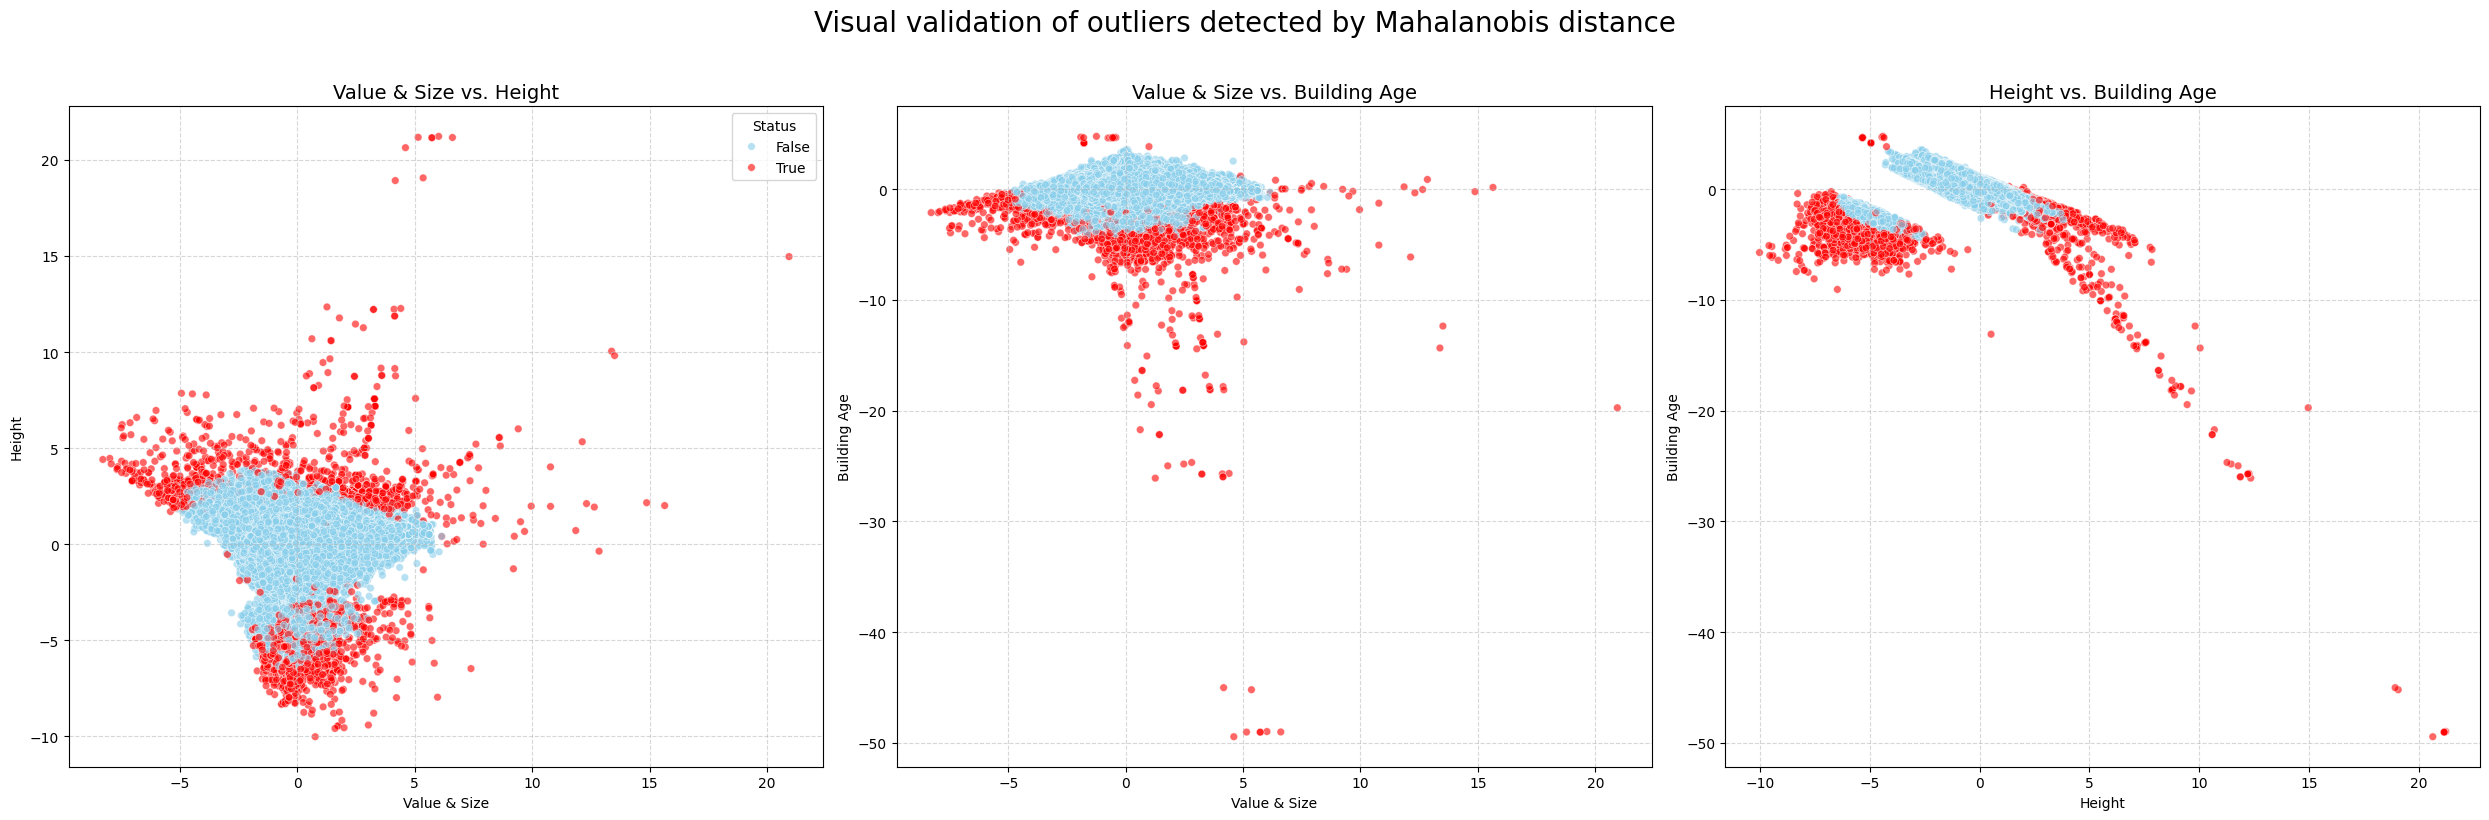

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

pc_pairs = [
    ('Value & Size', 'Height'),
    ('Value & Size', 'Building Age'),
    ('Height', 'Building Age')
]

fig, axes = plt.subplots(1, 3, figsize=(25, 8))

plt.suptitle('Visual validation of outliers detected by Mahalanobis distance', fontsize=20, y=1.02)

for i, (pc_x, pc_y) in enumerate(pc_pairs):
    ax = axes[i]
    
    sns.scatterplot(
        data=df, 
        x=pc_x, 
        y=pc_y, 
        hue='is_outlier_mahalanobis', 
        palette={True: 'red', False: 'skyblue'}, 
        alpha=0.6, 
        s=30,
        hue_order=[False, True], 
        ax=ax
    )
    
    ax.set_title(f'{pc_x} vs. {pc_y}', fontsize=14)
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        ax.legend(title='Status')
    else:
        ax.legend_.remove()

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()